# 🧮 11-01 · ARMA 与 ARIMA：经典统计预测

> 目标：第一个"正经"预测模型。手写 **AR 估计（OLS）、MA 估计（网格搜索）、AIC 定阶**，
> 用 ACF/PACF 识别阶数，完成「模拟 → 识别 → 估计 → 预测」完整链路。

> 🧩 **生活化类比**：AR = "我用前几天的值预测今天"（昨天 30°C，今天大概也 30°C）；
> MA = "我用前几天的预测误差修正今天"（昨天预报偏了 +2°，今天补回来）。
> ARIMA = 先差分把趋势去掉，再做 ARMA。


## 1. 三类模型定义

- **AR(p)**：$y_t = c + \\phi_1 y_{t-1} + \\cdots + \\phi_p y_{t-p} + \\epsilon_t$
  —— 用**历史观测**回归
- **MA(q)**：$y_t = \\mu + \\epsilon_t + \\theta_1 \\epsilon_{t-1} + \\cdots + \\theta_q \\epsilon_{t-q}$
  —— 用**历史误差**回归（记忆短）
- **ARMA(p,q)**：两者相加；**ARIMA(p,d,q)**：先做 d 阶差分再拟合 ARMA

**平稳性条件**：AR 特征方程根在单位圆外（|φ|<1 for AR(1)）；MA 永远平稳（有限记忆）。


真实 φ=0.85 | 估计 截距=-0.036 φ=0.852
AR(2) 真实 φ=[0.6,0.25] | 估计 [0.522 0.304]


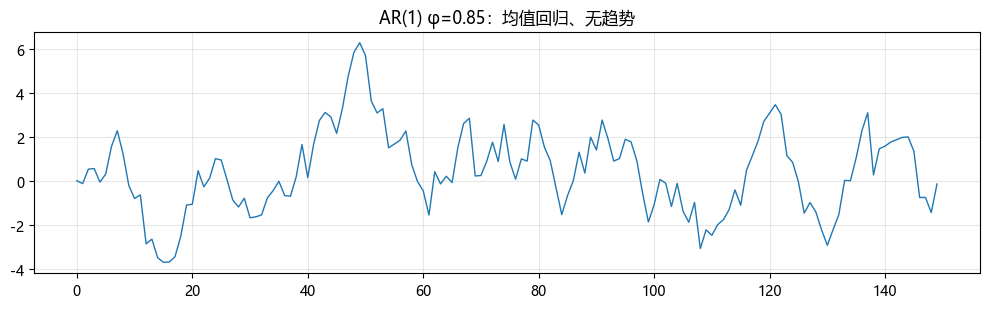

要点：AR 的估计就是线性回归——时间序列的"机器学习"起点


In [1]:
# ---------- 实验 1：手写模拟 + AR 的 OLS 估计 ----------
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
rng = np.random.default_rng(0)

def simulate_ar(phi, n=300, c=0.0, sigma=1.0):
    p = len(phi)
    y = np.zeros(n)
    e = rng.normal(0, sigma, n)
    for t in range(max(p, 1), n):
        y[t] = c + sum(phi[k] * y[t - 1 - k] for k in range(p)) + e[t]
    return y

y_ar1 = simulate_ar([0.85])            # AR(1): φ=0.85

def fit_ar(y, p):
    # OLS：y_t ~ [1, y_{t-1}, ..., y_{t-p}]
    X = np.stack([np.ones(len(y) - p)] + [y[p - 1 - k: len(y) - 1 - k] for k in range(p)], axis=1)
    beta, *_ = np.linalg.lstsq(X, y[p:], rcond=None)
    return beta

beta = fit_ar(y_ar1, 1)
print('真实 φ=0.85 | 估计 截距=%.3f φ=%.3f' % (beta[0], beta[1]))
assert abs(beta[1] - 0.85) < 0.08

# AR(2) 也能估
y_ar2 = simulate_ar([0.6, 0.25])
beta2 = fit_ar(y_ar2, 2)
print('AR(2) 真实 φ=[0.6,0.25] | 估计', np.round(beta2[1:], 3))
assert np.allclose(beta2[1:], [0.6, 0.25], atol=0.1)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(y_ar1[:150], lw=1); ax.set_title('AR(1) φ=0.85：均值回归、无趋势'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts01_ar.png', dpi=110, bbox_inches='tight'); plt.show()
print('要点：AR 的估计就是线性回归——时间序列的"机器学习"起点')


## 2. 模型识别：ACF 与 PACF 的指纹

| 模型 | ACF | PACF |
|------|-----|------|
| AR(p) | 拖尾（缓慢衰减） | **p 阶后截尾** |
| MA(q) | **q 阶后截尾** | 拖尾 |
| ARMA | 都拖尾 | 都拖尾 |

> 面试点：**看 ACF 定 MA 阶、看 PACF 定 AR 阶**。


AR(1): PACF 第 2 项后应落在 ±0.11 内 -> [-0.032 -0.025  0.013]
MA(1): ACF 第 2 项后应落在 ±0.11 内 -> [0.049 0.077 0.   ]


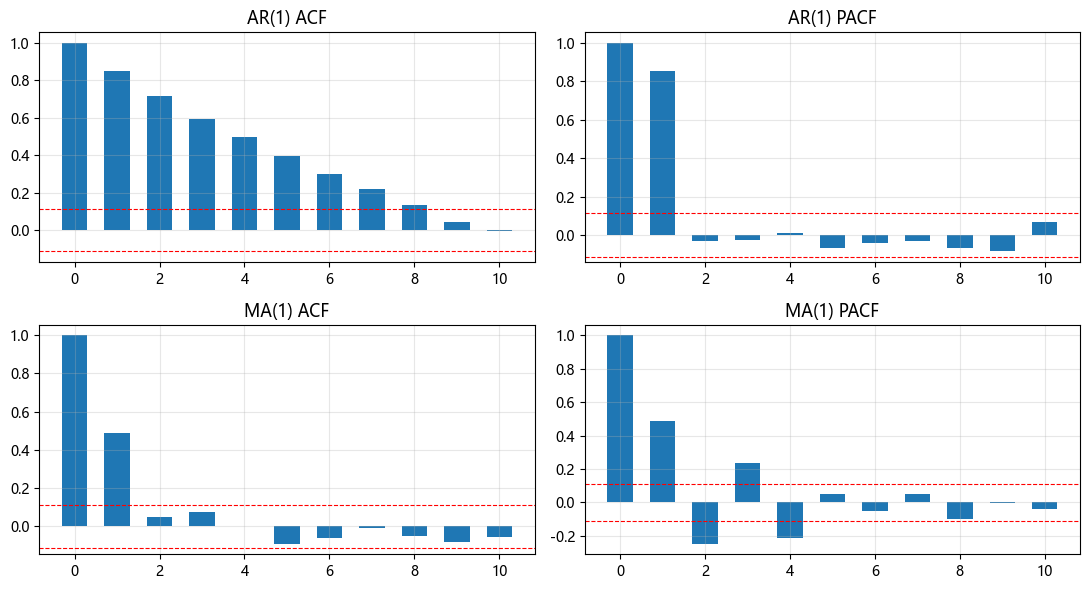

读图：AR(1) 的 PACF 在第 1 阶后截尾；MA(1) 的 ACF 在第 1 阶后截尾


In [2]:
# ---------- 实验 2：ACF/PACF 识别 AR 与 MA ----------
def acf(x, max_lag=20):
    x = x - x.mean()
    v = np.dot(x, x)
    out = [1.0]                                        # ρ(0) ≡ 1，注意 x[:-0] 是空数组
    for k in range(1, max_lag + 1):
        out.append(np.dot(x[k:], x[:-k]) / v)
    return np.array(out)

def pacf(x, max_lag=10):
    out = [1.0]
    for k in range(1, max_lag + 1):
        X = np.stack([x[k - j:-j] for j in range(k, 0, -1)], axis=1)   # 首列=最远滞后 x_{t-k}
        beta, *_ = np.linalg.lstsq(X, x[k:], rcond=None)
        out.append(float(beta[0]))                       # PACF(k) = x_{t-k} 的系数
    return np.array(out)

def simulate_ma(theta, n=300, sigma=1.0):
    q = len(theta)
    e = rng.normal(0, sigma, n)
    y = np.zeros(n)
    for t in range(1, n):
        y[t] = e[t] + sum(theta[k] * e[t - 1 - k] for k in range(min(q, t)))
    return y

y_ma1 = simulate_ma([0.7])
a1, p1 = acf(y_ar1, 10), pacf(y_ar1, 10)
a2, p2 = acf(y_ma1, 10), pacf(y_ma1, 10)
band = 1.96 / np.sqrt(len(y_ar1))
print('AR(1): PACF 第 2 项后应落在 ±%.2f 内 -> %s' % (band, np.round(p1[2:5], 3)))
print('MA(1): ACF 第 2 项后应落在 ±%.2f 内 -> %s' % (band, np.round(a2[2:5], 3)))
assert np.abs(p1[2:6]).max() < band * 1.2 and np.abs(a2[2:6]).max() < band * 1.2

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, title, v in [(axes[0, 0], 'AR(1) ACF', a1), (axes[0, 1], 'AR(1) PACF', p1),
                     (axes[1, 0], 'MA(1) ACF', a2), (axes[1, 1], 'MA(1) PACF', p2)]:
    ax.bar(range(len(v)), v, width=0.6); ax.axhline(band, ls='--', c='r', lw=0.8); ax.axhline(-band, ls='--', c='r', lw=0.8)
    ax.set_title(title); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts01_acf.png', dpi=110, bbox_inches='tight'); plt.show()
print('读图：AR(1) 的 PACF 在第 1 阶后截尾；MA(1) 的 ACF 在第 1 阶后截尾')


## 3. MA 估计：网格搜索（残差平方和最小）

MA 无法直接 OLS（误差项不可观测）——用迭代/数值优化：给定 θ，递推恢复 ε，最小化 $\\sum \\epsilon_t^2$。


In [3]:
# ---------- 实验 3：手写 MA(1) 网格搜索估计 ----------
def ma_resid_sse(theta, y, mu):
    n = len(y)
    e = np.zeros(n)
    sse = 0.0
    for t in range(n):
        e[t] = y[t] - mu - (theta * e[t - 1] if t > 0 else 0.0)
        sse += e[t] ** 2
    return sse

mu_hat = y_ma1.mean()
grid = np.linspace(-0.99, 0.99, 200)
sse = [ma_resid_sse(th, y_ma1, mu_hat) for th in grid]
th_best = grid[int(np.argmin(sse))]
print('真实 θ=0.7 | 网格搜索估计 θ=%.3f' % th_best)
assert abs(th_best - 0.7) < 0.1
print('要点：MA 的估计靠"反解误差"；阶数越高计算越贵，工业界常用信息准则自动定阶')


真实 θ=0.7 | 网格搜索估计 θ=0.751
要点：MA 的估计靠"反解误差"；阶数越高计算越贵，工业界常用信息准则自动定阶


## 4. ARIMA：差分 + ARMA + AIC 定阶

- **AIC** $= -2\\ln L + 2k$；**BIC** $= -2\\ln L + k\\ln n$（k=参数个数）
- 定阶流程：d（看 ADF/差分几次平稳）→ p/q（看 ACF/PACF 或**网格扫 AIC 最小**）
- 预测：AR 部分递归外推；置信区间随步长扩张


AR(2) 序列各阶 AIC: {1: np.float64(14.26), 2: np.float64(-10.96), 3: np.float64(-8.48)}
AIC 选出 p = 2


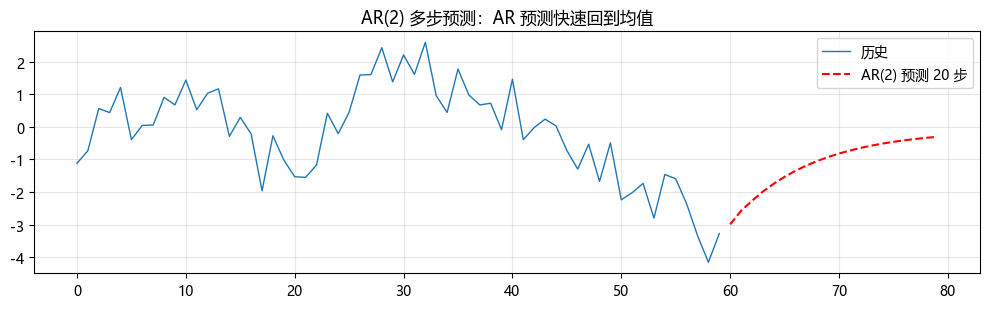

要点：平稳 AR 的长期预测收敛到均值——"回归均值"是平稳序列的核心性质


In [4]:
# ---------- 实验 4：手写 AIC 定阶 + AR 预测 ----------
def aic_ar(y, p, d=0):
    z = np.diff(y, d) if d > 0 else y
    beta = fit_ar(z, p)
    resid = z[p:] - np.stack([np.ones(len(z) - p)] +
                             [z[p - 1 - k: len(z) - 1 - k] for k in range(p)], axis=1) @ beta
    n = len(resid)
    sse = resid @ resid
    k = p + 1
    return n * np.log(sse / n) + 2 * k          # 高斯似然近似

aics = {p: aic_ar(y_ar2, p) for p in range(1, 4)}
print('AR(2) 序列各阶 AIC:', {p: round(v, 2) for p, v in aics.items()})
best = min(aics, key=aics.get)
print('AIC 选出 p =', best)
assert best == 2

# 用 AR(2) 做多步预测
def ar_forecast(y, p, h=20):
    beta = fit_ar(y, p)
    yf = list(y)
    for _ in range(h):
        idx = len(yf)
        yf.append(beta[0] + sum(beta[k + 1] * yf[idx - 1 - k] for k in range(p)))
    return np.array(yf)

yf = ar_forecast(y_ar2, 2, 20)
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(y_ar2[-60:], lw=1, label='历史')
ax.plot(np.arange(60, 80), yf[-20:], 'r--', lw=1.5, label='AR(2) 预测 20 步')
ax.legend(); ax.set_title('AR(2) 多步预测：AR 预测快速回到均值'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('images/ts01_fc.png', dpi=110, bbox_inches='tight'); plt.show()
print('要点：平稳 AR 的长期预测收敛到均值——"回归均值"是平稳序列的核心性质')


## 5. 数字敏感度与易错点（背诵）

**数字**
- AR(1) 平稳条件 |φ|<1；AR(p) 特征根在单位圆外
- AIC 与 BIC 的惩罚项：2k vs k·ln n（BIC 更狠，大样本选更简模型）
- 差分 d 的选择：ADF 检验不平稳就再差一阶（通常 d≤2）

**易错点**
1. MA 项**不能** OLS 直接估——误差不可观测，要迭代/数值优化
2. 定阶先看 ACF/PACF 再验证 AIC，不要只信一个
3. ARIMA 预测的是**差分后**序列，要**还原**（累积差分）才是原始尺度
4. 别对非平稳序列直接拟合 ARMA——参数估计无意义


## 6. 面试速答（30 秒背诵版）

- **AR**：历史观测回归；**MA**：历史误差回归；**ARMA/ARIMA**：组合 + 差分
- **识别**：PACF 截尾→AR(p)；ACF 截尾→MA(q)；都拖尾→ARMA
- **估计**：AR 用 OLS；MA/ARMA 用数值优化（如 MLE）
- **定阶**：AIC/BIC 网格；BIC 更严
- **预测性质**：平稳 AR 长期预测收敛均值
- **实战**：ARIMA 适合单变量、中等长度、无强非线性；复杂场景交给机器学习/深度模型


## 7. 自测清单

- [ ] 默写 AR(p)/MA(q)/ARMA 公式与平稳条件
- [ ] 手写 AR 的 OLS 估计（构造滞后矩阵）
- [ ] 手写 MA(1) 网格搜索（反解误差 + SSE）
- [ ] 手写 AIC 并完成 p 的自动选择
- [ ] 用 ACF/PACF 图识别 AR(1)/MA(1)
- [ ] 手写 AR 多步预测并解释"回归均值"
- [ ] 说清 ARIMA 预测后为什么要还原差分

> 💡 下一篇 `02-指数平滑` 用更轻量的递推方式做预测。
